# Baseline Training — Customer Churn Prediction

**Project:** Customer Churn Prediction  
**Notebook:** 03 — Baseline Training  
**Depends on:** `02_preprocessing.ipynb`  
**Keputusan:** `01_eda/01_eda_decisions_model_selection.md`

---

## Alur Notebook

```
Load preprocessed splits
  ├─► BAGIAN 1 — Balancing Strategy
  │     ├── Strategi A: class_weight
  │     └── Strategi B: SMOTE
  ├─► BAGIAN 2 — Baseline Training (10 kombinasi)
  │     ├── Tier 1 : XGBoost x {class_weight, SMOTE}
  │     ├── Tier 1 : LightGBM x {class_weight, SMOTE}
  │     ├── Tier 2 : Random Forest x {class_weight, SMOTE}
  │     ├── Tier 2 : Logistic Regression x {class_weight, SMOTE}
  │     └── Ensemble: Voting (XGB+LGBM+RF) x {class_weight, SMOTE}
  ├─► BAGIAN 3 — Ringkasan Hasil
  └─► BAGIAN 4 — Kriteria Seleksi untuk Tuning
```

**Primary metric: PR-AUC** — paling informatif untuk imbalanced dataset (3.44x, Insight 5).  
**Accuracy tidak digunakan** — baseline 77.5% dicapai tanpa belajar apapun.

---
## Install & Import

In [1]:
!pip install wandb imbalanced-learn lightgbm xgboost --quiet
print('OK install selesai.')

OK install selesai.


In [2]:
import os, warnings, json, time
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, recall_score, precision_score,
    classification_report
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import joblib
import wandb

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('OK import selesai.')

OK import selesai.


---
## Konstanta Global

In [3]:
# Path — output dari 02_preprocessing.ipynb
PREPROCESSING_OUTPUT = '/kaggle/input/notebooks/ardiyanto24/tccp-preprocessing-v2/artifacts'
SPLITS_JOBLIB_PATH   = f'{PREPROCESSING_OUTPUT}/splits.joblib'
OUTPUT_DIR           = '/kaggle/working/artifacts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# WandB
WANDB_PROJECT        = 'customer-churn-prediction'
WANDB_BASELINE_GROUP = 'baseline-training'

# Reproducibility
RANDOM_SEED = 42

# Imbalance ratio dari Insight 5 EDA
# Digunakan untuk scale_pos_weight XGBoost
IMBALANCE_RATIO = 3.44

# Primary metric
PRIMARY_METRIC = 'val_pr_auc'

# Kriteria seleksi untuk tuning
RECALL_MIN_THRESHOLD = 0.75
OVERFIT_GAP_MAX      = 0.02

print('OK konstanta global terdefinisi.')
print(f'   SPLITS_JOBLIB_PATH : {SPLITS_JOBLIB_PATH}')
print(f'   PRIMARY_METRIC     : {PRIMARY_METRIC}')
print(f'   IMBALANCE_RATIO    : {IMBALANCE_RATIO}x')

OK konstanta global terdefinisi.
   SPLITS_JOBLIB_PATH : /kaggle/input/notebooks/ardiyanto24/tccp-preprocessing-v2/artifacts/splits.joblib
   PRIMARY_METRIC     : val_pr_auc
   IMBALANCE_RATIO    : 3.44x


---
## Deklarasi Model Registry

In [4]:
def get_model_registry() -> dict:
    '''
    Kembalikan dict berisi semua kandidat model.
    Format: {model_name: {class_weight: instance, smote: instance, tier: int}}

    Tier 1 — XGBoost:
      Regularisasi L1/L2, scale_pos_weight built-in (Insight 5 imbalance 3.44x)
      Tree split menangkap interaksi Contract x Internet x tenure (Insight 35, 48)

    Tier 1 — LightGBM:
      Leaf-wise growth, 5-10x lebih cepat untuk 594K baris
      Efisien untuk banyak trial Optuna nantinya

    Tier 2 — Random Forest:
      Bagging, lower bound untuk boosting
      Konfirmasi: apakah boosting diperlukan?

    Tier 2 — Logistic Regression:
      Lower bound linear
      Konfirmasi non-linearity data dari EDA (Insight 35, 58)

    Ensemble — Voting (XGB+LGBM+RF):
      Soft voting, probabilitas lebih terkalibrasi di overlap zone 67K (Insight 56)
    '''
    return {

        # Tier 1: XGBoost
        'xgboost': {
            'class_weight': XGBClassifier(
                n_estimators=300, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=IMBALANCE_RATIO,
                use_label_encoder=False, eval_metric='aucpr',
                random_state=RANDOM_SEED, n_jobs=-1, verbosity=0
            ),
            'smote': XGBClassifier(
                n_estimators=300, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                use_label_encoder=False, eval_metric='aucpr',
                random_state=RANDOM_SEED, n_jobs=-1, verbosity=0
            ),
            'tier': 1
        },

        # Tier 1: LightGBM
        'lightgbm': {
            'class_weight': LGBMClassifier(
                n_estimators=300, num_leaves=63, learning_rate=0.05,
                feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                is_unbalance=True,
                random_state=RANDOM_SEED, n_jobs=-1, verbosity=-1
            ),
            'smote': LGBMClassifier(
                n_estimators=300, num_leaves=63, learning_rate=0.05,
                feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
                random_state=RANDOM_SEED, n_jobs=-1, verbosity=-1
            ),
            'tier': 1
        },

        # Tier 2: Random Forest
        'random_forest': {
            'class_weight': RandomForestClassifier(
                n_estimators=300, max_depth=None,
                class_weight='balanced',
                random_state=RANDOM_SEED, n_jobs=-1
            ),
            'smote': RandomForestClassifier(
                n_estimators=300, max_depth=None,
                random_state=RANDOM_SEED, n_jobs=-1
            ),
            'tier': 2
        },

        # Tier 2: Logistic Regression
        'logistic_regression': {
            'class_weight': LogisticRegression(
                C=1.0, class_weight='balanced',
                max_iter=1000, random_state=RANDOM_SEED, n_jobs=-1
            ),
            'smote': LogisticRegression(
                C=1.0, max_iter=1000,
                random_state=RANDOM_SEED, n_jobs=-1
            ),
            'tier': 2
        },
    }


print('OK model registry terdefinisi.')
registry = get_model_registry()
for name, info in registry.items():
    print(f'   Tier {info["tier"]} | {name}')

OK model registry terdefinisi.
   Tier 1 | xgboost
   Tier 1 | lightgbm
   Tier 2 | random_forest
   Tier 2 | logistic_regression


---
## Deklarasi Class & Function

In [5]:
# CLASS: BalancingStrategy
# Dasar EDA: Insight 5 (imbalance 3.44x)

class BalancingStrategy:
    '''
    A. class_weight: tidak mengubah data, loss weighting di model.
       Direkomendasikan sebagai baseline untuk imbalance moderat (3.44x).
    B. SMOTE: oversampling minority class DI training set saja.
       Val dan test TIDAK boleh disentuh.
    '''

    @staticmethod
    def apply_smote(X_train, y_train, random_state=RANDOM_SEED):
        smote = SMOTE(random_state=random_state)
        X_res, y_res = smote.fit_resample(X_train, y_train)
        print(f'  SMOTE applied:')
        print(f'    Before: {len(y_train):,} | Churn=1: {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
        print(f'    After : {len(y_res):,} | Churn=1: {y_res.sum():,} ({y_res.mean()*100:.1f}%)')
        return X_res, y_res

    @staticmethod
    def apply_class_weight(X_train, y_train):
        print(f'  class_weight: {len(y_train):,} samples, imbalance handled di model.')
        return X_train, y_train


print('OK BalancingStrategy terdefinisi.')

OK BalancingStrategy terdefinisi.


In [6]:
# CLASS: MetricsCalculator
# Primary: PR-AUC | Secondary: ROC-AUC, F1, Recall, Precision

class MetricsCalculator:
    '''
    PR-AUC sebagai primary metric karena:
    - Paling informatif untuk imbalanced dataset
    - Fokus pada performa di kelas positif (minority)
    - ROC-AUC bisa bagus meski model buruk di kelas minority

    Accuracy TIDAK dihitung: baseline 77.5% tanpa belajar (Insight 5).
    Recall diprioritaskan monitoring: missed churn lebih mahal dari false alarm.
    '''

    @staticmethod
    def compute(y_true, y_prob, threshold=0.5, prefix=''):
        y_pred = (y_prob >= threshold).astype(int)
        return {
            f'{prefix}pr_auc'         : average_precision_score(y_true, y_prob),
            f'{prefix}roc_auc'        : roc_auc_score(y_true, y_prob),
            f'{prefix}f1_churn'       : f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            f'{prefix}recall_churn'   : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            f'{prefix}precision_churn': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        }

    @staticmethod
    def print_metrics(metrics, title=''):
        if title:
            print(f'  {title}')
        for k, v in metrics.items():
            bar = chr(9608) * int(v * 20)
            print(f'    {k:30s}: {v:.4f}  {bar}')


print('OK MetricsCalculator terdefinisi.')

OK MetricsCalculator terdefinisi.


In [7]:
# CLASS: BaselineTrainer
# Orkestrasi training satu model + evaluasi + logging

class BaselineTrainer:
    '''
    Trainer untuk satu kombinasi (model x balance_strategy).
    Alur: balance -> fit -> metrics -> save -> wandb log -> return results
    '''

    def __init__(self, model_name, balance_strategy, model, tier, output_dir=OUTPUT_DIR):
        self.model_name       = model_name
        self.balance_strategy = balance_strategy
        self.model            = model
        self.tier             = tier
        self.output_dir       = output_dir

    def train(self, X_train, y_train, X_val, y_val, X_test, y_test, log_wandb=True):
        run_name = f'{self.model_name}__{self.balance_strategy}'
        print(f'\n{"="*60}')
        print(f'  Training: {run_name}  [Tier {self.tier}]')
        print('='*60)

        # 1. Balancing
        if self.balance_strategy == 'smote':
            X_tr, y_tr = BalancingStrategy.apply_smote(X_train, y_train)
        else:
            X_tr, y_tr = BalancingStrategy.apply_class_weight(X_train, y_train)

        # 2. Training
        t0 = time.time()
        try:
            self.model.fit(X_tr, y_tr)
            train_time = time.time() - t0
            print(f'  Training selesai dalam {train_time:.1f}s')
        except Exception as e:
            print(f'  GAGAL: {e}')
            return {'model_name': self.model_name, 'balance_strategy': self.balance_strategy,
                    'status': 'failed', 'error': str(e)}

        # 3. Metrics
        y_val_prob  = self.model.predict_proba(X_val)[:, 1]
        y_test_prob = self.model.predict_proba(X_test)[:, 1]
        val_m  = MetricsCalculator.compute(y_val,  y_val_prob,  prefix='val_')
        test_m = MetricsCalculator.compute(y_test, y_test_prob, prefix='test_')
        all_m  = {**val_m, **test_m, 'train_time_s': train_time}

        MetricsCalculator.print_metrics(val_m,  'Val  metrics:')
        MetricsCalculator.print_metrics(test_m, 'Test metrics:')

        # 4. Save model
        fname      = f'{self.model_name}__{self.balance_strategy}.joblib'
        model_path = os.path.join(self.output_dir, fname)
        joblib.dump(self.model, model_path)
        print(f'  Saved: {fname}')

        # 5. WandB
        if log_wandb:
            try:
                cfg = self.model.get_params() if hasattr(self.model, 'get_params') else {}
                with wandb.init(
                    project=WANDB_PROJECT, group=WANDB_BASELINE_GROUP,
                    name=run_name, tags=[f'tier-{self.tier}', self.balance_strategy, 'baseline'],
                    config={'model_name': self.model_name,
                            'balance_strategy': self.balance_strategy,
                            'tier': self.tier, **cfg}
                ) as run:
                    wandb.log(all_m)
                    if os.path.exists(model_path):
                        art = wandb.Artifact(f'baseline-{run_name}', type='model')
                        art.add_file(model_path)
                        run.log_artifact(art)
                print('  WandB: logged OK')
            except Exception as e:
                print(f'  WandB: gagal ({e})')

        return {
            'model_name': self.model_name, 'balance_strategy': self.balance_strategy,
            'tier': self.tier, 'model': self.model, 'model_path': model_path,
            'status': 'success', **all_m
        }


print('OK BaselineTrainer terdefinisi.')

OK BaselineTrainer terdefinisi.


In [8]:
# CLASS: VotingEnsembleBuilder
# Justifikasi: overlap zone 67K pelanggan churn rate 47.5% (Insight 56)
# Soft voting -> probabilitas lebih terkalibrasi di zona ambigu

class VotingEnsembleBuilder:
    '''
    Build Voting Ensemble (soft voting): XGBoost + LightGBM + Random Forest.

    Soft voting dipilih karena:
    - Probabilitas terkalibrasi -> threshold tuning bisa dilakukan
    - Var(ensemble) = sigma^2/n * [1+(n-1)*rho]
      Diversitas model (boosting x2 + bagging x1) -> rho rendah -> variance turun
    '''

    def __init__(self, balance_strategy):
        self.balance_strategy = balance_strategy

    def build(self, registry):
        base_models = [
            ('xgb',  registry['xgboost'][self.balance_strategy]),
            ('lgbm', registry['lightgbm'][self.balance_strategy]),
            ('rf',   registry['random_forest'][self.balance_strategy]),
        ]
        return VotingClassifier(estimators=base_models, voting='soft', n_jobs=-1)


print('OK VotingEnsembleBuilder terdefinisi.')
print()
print('OK Semua class terdefinisi. Siap eksekusi.')

OK VotingEnsembleBuilder terdefinisi.

OK Semua class terdefinisi. Siap eksekusi.


---
## Load Data Preprocessed

In [9]:
print('Loading preprocessed splits dari 02_preprocessing.ipynb...')

splits = joblib.load(SPLITS_JOBLIB_PATH)

X_train_arr   = splits['X_train']
X_val_arr     = splits['X_val']
X_test_arr    = splits['X_test']
y_train_arr   = splits['y_train']
y_val_arr     = splits['y_val']
y_test_arr    = splits['y_test']
feature_names = splits['feature_names']

print(f'Splits loaded:')
print(f'  X_train : {X_train_arr.shape}')
print(f'  X_val   : {X_val_arr.shape}')
print(f'  X_test  : {X_test_arr.shape}')
print(f'  Features: {len(feature_names)} kolom')
print()
for name, y in [('train', y_train_arr), ('val', y_val_arr), ('test', y_test_arr)]:
    print(f'  {name:5s}: Churn=1 {y.sum():>7,} / {len(y):>7,} ({y.mean()*100:.1f}%)')

Loading preprocessed splits dari 02_preprocessing.ipynb...
Splits loaded:
  X_train : (415935, 29)
  X_val   : (89129, 29)
  X_test  : (89130, 29)
  Features: 29 kolom

  train: Churn=1  93,672 / 415,935 (22.5%)
  val  : Churn=1  20,072 /  89,129 (22.5%)
  test : Churn=1  20,073 /  89,130 (22.5%)


---
## BAGIAN 1 — Balancing Strategy

In [10]:
# Strategi A: class_weight
print('=== STRATEGI A: CLASS WEIGHT ===')
print('Data tidak diubah. Class weight dikonfigurasi di model.')
print(f'  XGBoost     : scale_pos_weight = {IMBALANCE_RATIO}')
print(f'  LightGBM    : is_unbalance = True')
print(f'  RandomForest: class_weight = balanced')
print(f'  LogReg      : class_weight = balanced')
_, _ = BalancingStrategy.apply_class_weight(X_train_arr, y_train_arr)

=== STRATEGI A: CLASS WEIGHT ===
Data tidak diubah. Class weight dikonfigurasi di model.
  XGBoost     : scale_pos_weight = 3.44
  LightGBM    : is_unbalance = True
  RandomForest: class_weight = balanced
  LogReg      : class_weight = balanced
  class_weight: 415,935 samples, imbalance handled di model.


In [11]:
# Strategi B: SMOTE
# PENTING: hanya pada training set, val/test tidak disentuh
print('=== STRATEGI B: SMOTE ===')
print('PENTING: SMOTE hanya pada X_train. Val/test tidak disentuh.')
X_train_smote, y_train_smote = BalancingStrategy.apply_smote(
    X_train_arr, y_train_arr, random_state=RANDOM_SEED
)

=== STRATEGI B: SMOTE ===
PENTING: SMOTE hanya pada X_train. Val/test tidak disentuh.
  SMOTE applied:
    Before: 415,935 | Churn=1: 93,672 (22.5%)
    After : 644,526 | Churn=1: 322,263 (50.0%)


---
## BAGIAN 2 — Baseline Training

### Setup WandB

In [12]:
from kaggle_secrets import UserSecretsClient
secret = UserSecretsClient()
wandb.login(key=secret.get_secret('WANDB'))
print('OK WandB login selesai.')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ardiyanto24 (ardiyanto24-indonesian-national-police) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


OK WandB login selesai.


### Jalankan Semua Eksperimen (10 Kombinasi)

In [13]:
# 10 kombinasi: 8 model x 2 balancing + 2 ensemble
# Urutan: Tier 1 -> Tier 2 -> Ensemble
# Dalam setiap tier: class_weight dulu -> smote

registry = get_model_registry()
results  = []

experiments = [
    # Tier 1
    ('xgboost',            'class_weight', 1),
    ('xgboost',            'smote',        1),
    ('lightgbm',           'class_weight', 1),
    ('lightgbm',           'smote',        1),
    # Tier 2
    ('random_forest',      'class_weight', 2),
    ('random_forest',      'smote',        2),
    ('logistic_regression','class_weight', 2),
    ('logistic_regression','smote',        2),
]

for model_name, balance_strategy, tier in experiments:
    model = registry[model_name][balance_strategy]
    X_tr  = X_train_smote if balance_strategy == 'smote' else X_train_arr
    y_tr  = y_train_smote if balance_strategy == 'smote' else y_train_arr

    trainer = BaselineTrainer(
        model_name=model_name, balance_strategy=balance_strategy,
        model=model, tier=tier, output_dir=OUTPUT_DIR
    )
    result = trainer.train(
        X_tr, y_tr,
        X_val_arr, y_val_arr,
        X_test_arr, y_test_arr,
        log_wandb=True
    )
    results.append(result)

n_ok = len([r for r in results if r.get('status') == 'success'])
print(f'\nSelesai: {n_ok}/{len(results)} run berhasil')


  Training: xgboost__class_weight  [Tier 1]
  class_weight: 415,935 samples, imbalance handled di model.
  Training selesai dalam 7.6s
  Val  metrics:
    val_pr_auc                    : 0.7512  ███████████████
    val_roc_auc                   : 0.9152  ██████████████████
    val_f1_churn                  : 0.6838  █████████████
    val_recall_churn              : 0.8773  █████████████████
    val_precision_churn           : 0.5603  ███████████
  Test metrics:
    test_pr_auc                   : 0.7514  ███████████████
    test_roc_auc                  : 0.9154  ██████████████████
    test_f1_churn                 : 0.6833  █████████████
    test_recall_churn             : 0.8801  █████████████████
    test_precision_churn          : 0.5584  ███████████
  Saved: xgboost__class_weight.joblib


wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260328_093719-u3jvnb0n
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run xgboost__class_weight
wandb: ⭐️ View project at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction
wandb: 🚀 View run at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction/runs/u3jvnb0n
wandb: updating run metadata; uploading artifact baseline-xgboost__class_weight
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb:        test_f1_churn ▁
wandb:          test_pr_auc ▁
wandb: test_precision_churn ▁
wandb:    test_recall_churn ▁
wandb:         test_roc_auc ▁
wandb:         train_time_s ▁
wandb:         val_f1_churn ▁
wandb:           val_pr_auc ▁
wandb:  val_precision_churn ▁
wandb:     val_recall_churn ▁
wandb:                   +1 ...
wandb: 
wandb: Run summary:
wandb:        test_f1_churn 0.6833
wandb:

  WandB: logged OK

  Training: xgboost__smote  [Tier 1]
  SMOTE applied:
    Before: 644,526 | Churn=1: 322,263 (50.0%)
    After : 644,526 | Churn=1: 322,263 (50.0%)
  Training selesai dalam 11.3s
  Val  metrics:
    val_pr_auc                    : 0.7479  ██████████████
    val_roc_auc                   : 0.9132  ██████████████████
    val_f1_churn                  : 0.6914  █████████████
    val_recall_churn              : 0.8348  ████████████████
    val_precision_churn           : 0.5900  ███████████
  Test metrics:
    test_pr_auc                   : 0.7479  ██████████████
    test_roc_auc                  : 0.9132  ██████████████████
    test_f1_churn                 : 0.6918  █████████████
    test_recall_churn             : 0.8394  ████████████████
    test_precision_churn          : 0.5883  ███████████
  Saved: xgboost__smote.joblib


wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260328_093734-5vzhs4y9
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run xgboost__smote
wandb: ⭐️ View project at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction
wandb: 🚀 View run at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction/runs/5vzhs4y9
wandb: updating run metadata; uploading artifact baseline-xgboost__smote
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb:        test_f1_churn ▁
wandb:          test_pr_auc ▁
wandb: test_precision_churn ▁
wandb:    test_recall_churn ▁
wandb:         test_roc_auc ▁
wandb:         train_time_s ▁
wandb:         val_f1_churn ▁
wandb:           val_pr_auc ▁
wandb:  val_precision_churn ▁
wandb:     val_recall_churn ▁
wandb:                   +1 ...
wandb: 
wandb: Run summary:
wandb:        test_f1_churn 0.69179
wandb:          tes

  WandB: logged OK

  Training: lightgbm__class_weight  [Tier 1]
  class_weight: 415,935 samples, imbalance handled di model.
  Training selesai dalam 8.7s
  Val  metrics:
    val_pr_auc                    : 0.7514  ███████████████
    val_roc_auc                   : 0.9150  ██████████████████
    val_f1_churn                  : 0.6835  █████████████
    val_recall_churn              : 0.8758  █████████████████
    val_precision_churn           : 0.5604  ███████████
  Test metrics:
    test_pr_auc                   : 0.7508  ███████████████
    test_roc_auc                  : 0.9152  ██████████████████
    test_f1_churn                 : 0.6831  █████████████
    test_recall_churn             : 0.8792  █████████████████
    test_precision_churn          : 0.5585  ███████████
  Saved: lightgbm__class_weight.joblib


...

  WandB: logged OK

  Training: logistic_regression__class_weight  [Tier 2]
  class_weight: 415,935 samples, imbalance handled di model.
  Training selesai dalam 4.8s
  Val  metrics:
    val_pr_auc                    : 0.7410  ██████████████
    val_roc_auc                   : 0.9122  ██████████████████
    val_f1_churn                  : 0.6772  █████████████
    val_recall_churn              : 0.8795  █████████████████
    val_precision_churn           : 0.5505  ███████████
  Test metrics:
    test_pr_auc                   : 0.7406  ██████████████
    test_roc_auc                  : 0.9117  ██████████████████
    test_f1_churn                 : 0.6754  █████████████
    test_recall_churn             : 0.8805  █████████████████
    test_precision_churn          : 0.5477  ██████████
  Saved: logistic_regression__class_weight.joblib


wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260328_094349-gh8s57o2
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run logistic_regression__class_weight
wandb: ⭐️ View project at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction
wandb: 🚀 View run at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction/runs/gh8s57o2
wandb: updating run metadata; uploading summary; uploading artifact baseline-logistic_regression__class_weight
wandb: 
wandb: Run history:
wandb:        test_f1_churn ▁
wandb:          test_pr_auc ▁
wandb: test_precision_churn ▁
wandb:    test_recall_churn ▁
wandb:         test_roc_auc ▁
wandb:         train_time_s ▁
wandb:         val_f1_churn ▁
wandb:           val_pr_auc ▁
wandb:  val_precision_churn ▁
wandb:     val_recall_churn ▁
wandb:                   +1 ...
wandb: 
wandb: Run summary:
wandb:        test_f1_churn 0.67535
wandb:

  WandB: logged OK

  Training: logistic_regression__smote  [Tier 2]
  SMOTE applied:
    Before: 644,526 | Churn=1: 322,263 (50.0%)
    After : 644,526 | Churn=1: 322,263 (50.0%)
  Training selesai dalam 4.7s
  Val  metrics:
    val_pr_auc                    : 0.7407  ██████████████
    val_roc_auc                   : 0.9121  ██████████████████
    val_f1_churn                  : 0.6777  █████████████
    val_recall_churn              : 0.8786  █████████████████
    val_precision_churn           : 0.5516  ███████████
  Test metrics:
    test_pr_auc                   : 0.7405  ██████████████
    test_roc_auc                  : 0.9117  ██████████████████
    test_f1_churn                 : 0.6756  █████████████
    test_recall_churn             : 0.8791  █████████████████
    test_precision_churn          : 0.5485  ██████████
  Saved: logistic_regression__smote.joblib


wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260328_094356-d0g13xgq
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run logistic_regression__smote
wandb: ⭐️ View project at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction
wandb: 🚀 View run at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction/runs/d0g13xgq
wandb: updating run metadata; uploading summary; uploading artifact baseline-logistic_regression__smote
wandb: uploading wandb-metadata.json; uploading requirements.txt; uploading wandb-summary.json; uploading config.yaml
wandb: 
wandb: Run history:
wandb:        test_f1_churn ▁
wandb:          test_pr_auc ▁
wandb: test_precision_churn ▁
wandb:    test_recall_churn ▁
wandb:         test_roc_auc ▁
wandb:         train_time_s ▁
wandb:         val_f1_churn ▁
wandb:           val_pr_auc ▁
wandb:  val_precision_churn ▁
wandb:     val_recall_churn 

  WandB: logged OK

Selesai: 8/8 run berhasil


### Build & Train Voting Ensemble

In [14]:
# Voting Ensemble (XGB + LGBM + RF), soft voting
# Base models sudah di-fit di loop sebelumnya
# Justifikasi: overlap zone 67K (Insight 56), soft voting -> kalibrasi lebih baik

for balance_strategy in ['class_weight', 'smote']:
    print(f'\n{"="*60}')
    print(f'  Voting Ensemble -- {balance_strategy}  [Ensemble]')
    print('='*60)

    builder  = VotingEnsembleBuilder(balance_strategy=balance_strategy)
    ensemble = builder.build(registry)

    X_tr = X_train_smote if balance_strategy == 'smote' else X_train_arr
    y_tr = y_train_smote if balance_strategy == 'smote' else y_train_arr

    t0 = time.time()
    ensemble.fit(X_tr, y_tr)
    train_time = time.time() - t0
    print(f'  Training selesai dalam {train_time:.1f}s')

    y_val_prob  = ensemble.predict_proba(X_val_arr)[:, 1]
    y_test_prob = ensemble.predict_proba(X_test_arr)[:, 1]
    val_m  = MetricsCalculator.compute(y_val_arr,  y_val_prob,  prefix='val_')
    test_m = MetricsCalculator.compute(y_test_arr, y_test_prob, prefix='test_')
    all_m  = {**val_m, **test_m, 'train_time_s': train_time}

    MetricsCalculator.print_metrics(val_m,  'Val  metrics:')
    MetricsCalculator.print_metrics(test_m, 'Test metrics:')

    fname      = f'voting_ensemble__{balance_strategy}.joblib'
    model_path = os.path.join(OUTPUT_DIR, fname)
    joblib.dump(ensemble, model_path)
    print(f'  Saved: {fname}')

    try:
        with wandb.init(
            project=WANDB_PROJECT, group=WANDB_BASELINE_GROUP,
            name=f'voting_ensemble__{balance_strategy}',
            tags=['ensemble', balance_strategy, 'baseline'],
            config={'model_name': 'voting_ensemble',
                    'balance_strategy': balance_strategy,
                    'base_models': 'xgboost+lightgbm+random_forest',
                    'voting': 'soft'}
        ) as run:
            wandb.log(all_m)
            art = wandb.Artifact(f'baseline-voting-{balance_strategy}', type='model')
            art.add_file(model_path)
            run.log_artifact(art)
        print('  WandB: logged OK')
    except Exception as e:
        print(f'  WandB: gagal ({e})')

    results.append({
        'model_name': 'voting_ensemble', 'balance_strategy': balance_strategy,
        'tier': 0, 'model': ensemble, 'model_path': model_path,
        'status': 'success', **all_m
    })


  Voting Ensemble -- class_weight  [Ensemble]
  Training selesai dalam 186.3s
  Val  metrics:
    val_pr_auc                    : 0.7406  ██████████████
    val_roc_auc                   : 0.9132  ██████████████████
    val_f1_churn                  : 0.6976  █████████████
    val_recall_churn              : 0.8183  ████████████████
    val_precision_churn           : 0.6079  ████████████
  Test metrics:
    test_pr_auc                   : 0.7413  ██████████████
    test_roc_auc                  : 0.9132  ██████████████████
    test_f1_churn                 : 0.6987  █████████████
    test_recall_churn             : 0.8219  ████████████████
    test_precision_churn          : 0.6075  ████████████
  Saved: voting_ensemble__class_weight.joblib


wandb: setting up run a6epz5qs
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260328_094721-a6epz5qs
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run voting_ensemble__class_weight
wandb: ⭐️ View project at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction
wandb: 🚀 View run at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction/runs/a6epz5qs
wandb: uploading artifact baseline-voting-class_weight; updating run metadata
wandb: uploading artifact baseline-voting-class_weight
wandb: uploading artifact baseline-voting-class_weight; uploading summary
wandb: uploading artifact baseline-voting-class_weight
wandb: 
wandb: Run history:
wandb:        test_f1_churn ▁
wandb:          test_pr_auc ▁
wandb: test_precision_churn ▁
wandb:    test_recall_churn ▁
wandb:         test_roc_auc ▁
wandb:         train_time_s ▁
wandb:         val_f1_churn ▁
wandb:        

  WandB: logged OK

  Voting Ensemble -- smote  [Ensemble]
  Training selesai dalam 355.4s
  Val  metrics:
    val_pr_auc                    : 0.7395  ██████████████
    val_roc_auc                   : 0.9119  ██████████████████
    val_f1_churn                  : 0.6970  █████████████
    val_recall_churn              : 0.7937  ███████████████
    val_precision_churn           : 0.6213  ████████████
  Test metrics:
    test_pr_auc                   : 0.7408  ██████████████
    test_roc_auc                  : 0.9119  ██████████████████
    test_f1_churn                 : 0.6955  █████████████
    test_recall_churn             : 0.7957  ███████████████
    test_precision_churn          : 0.6178  ████████████
  Saved: voting_ensemble__smote.joblib


wandb: setting up run trr10ige
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260328_095533-trr10ige
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run voting_ensemble__smote
wandb: ⭐️ View project at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction
wandb: 🚀 View run at https://wandb.ai/ardiyanto24-indonesian-national-police/customer-churn-prediction/runs/trr10ige
wandb: uploading artifact baseline-voting-smote
wandb: uploading artifact baseline-voting-smote; uploading summary
wandb: uploading artifact baseline-voting-smote
wandb: 
wandb: Run history:
wandb:        test_f1_churn ▁
wandb:          test_pr_auc ▁
wandb: test_precision_churn ▁
wandb:    test_recall_churn ▁
wandb:         test_roc_auc ▁
wandb:         train_time_s ▁
wandb:         val_f1_churn ▁
wandb:           val_pr_auc ▁
wandb:  val_precision_churn ▁
wandb:     val_recall_churn ▁
wandb:                   +1 ..

  WandB: logged OK


---
## BAGIAN 3 — Ringkasan Hasil

In [15]:
print('=== RINGKASAN HASIL BASELINE TRAINING ===')
print('Diurutkan berdasarkan val_pr_auc (primary metric)\n')

display_cols = [
    'model_name', 'balance_strategy', 'tier',
    'val_pr_auc', 'val_roc_auc', 'val_f1_churn',
    'val_recall_churn', 'val_precision_churn',
    'test_pr_auc', 'test_roc_auc', 'train_time_s', 'status'
]

success_results = [r for r in results if r.get('status') == 'success']
results_df = (
    pd.DataFrame(success_results)[display_cols]
    .sort_values('val_pr_auc', ascending=False)
    .reset_index(drop=True)
)
display(results_df.round(4))

=== RINGKASAN HASIL BASELINE TRAINING ===
Diurutkan berdasarkan val_pr_auc (primary metric)



,model_name,balance_strategy,tier,val_pr_auc,val_roc_auc,val_f1_churn,val_recall_churn,val_precision_churn,test_pr_auc,test_roc_auc,train_time_s,status
0,lightgbm,class_weight,1,0.7514,0.9150,0.6835,0.8758,0.5604,0.7508,0.9152,8.7011,success
1,xgboost,class_weight,1,0.7512,0.9152,0.6838,0.8773,0.5603,0.7514,0.9154,7.5784,success
2,xgboost,smote,1,0.7479,0.9132,0.6914,0.8348,0.5900,0.7479,0.9132,11.2703,success
3,lightgbm,smote,1,0.7464,0.9133,0.6986,0.7796,0.6327,0.7463,0.9133,19.1660,success
4,logistic_regression,class_weight,2,0.7410,0.9122,0.6772,0.8795,0.5505,0.7406,0.9117,4.7687,success
5,logistic_regression,smote,2,0.7407,0.9121,0.6777,0.8786,0.5516,0.7405,0.9117,4.6817,success
6,voting_ensemble,class_weight,0,0.7406,0.9132,0.6976,0.8183,0.6079,0.7413,0.9132,186.3097,success
7,voting_ensemble,smote,0,0.7395,0.9119,0.6970,0.7937,0.6213,0.7408,0.9119,355.3598,success
8,random_forest,class_weight,2,0.7021,0.8979,0.6309,0.5848,0.6848,0.7033,0.8976,87.9843,success
9,random_forest,smote,2,0.6876,0.8956,0.6615,0.7133,0.6167,0.6894,0.8956,167.8658,success


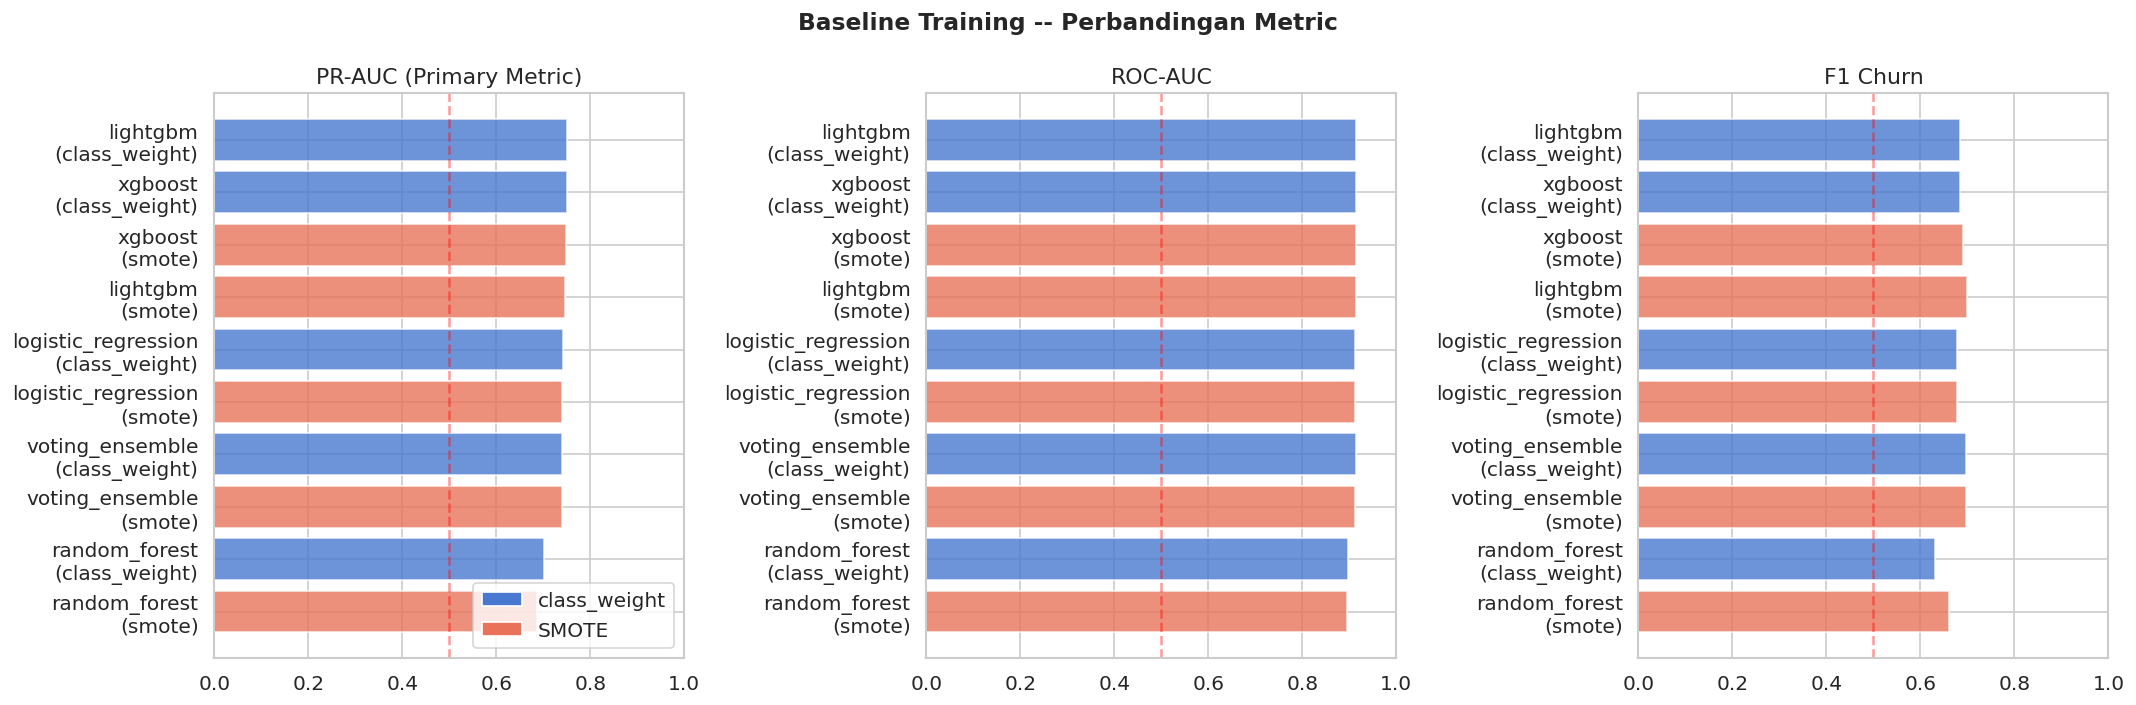

In [16]:
# Visualisasi perbandingan
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Baseline Training -- Perbandingan Metric', fontsize=14, fontweight='bold')

metric_pairs = [
    ('val_pr_auc',   'PR-AUC (Primary Metric)'),
    ('val_roc_auc',  'ROC-AUC'),
    ('val_f1_churn', 'F1 Churn'),
]
colors = {'class_weight': '#4878CF', 'smote': '#E8735A'}

for ax, (metric, title) in zip(axes, metric_pairs):
    for _, row in results_df.iterrows():
        label = f'{row["model_name"]}\n({row["balance_strategy"]})'
        ax.barh(label, row[metric], color=colors.get(row['balance_strategy'], 'gray'), alpha=0.8)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.4)
    ax.invert_yaxis()

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor='#4878CF', label='class_weight'),
    Patch(facecolor='#E8735A', label='SMOTE')
], loc='lower right')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/baseline_comparison.png', bbox_inches='tight')
plt.show()

In [17]:
# Top 3 model
print('=== TOP 3 MODEL BASELINE ===')
print('(Berdasarkan val_pr_auc)\n')

results_df['gap_pr_auc']  = (results_df['val_pr_auc']  - results_df['test_pr_auc']).abs()
results_df['gap_roc_auc'] = (results_df['val_roc_auc'] - results_df['test_roc_auc']).abs()

for rank, (_, row) in enumerate(results_df.head(3).iterrows(), 1):
    flag = 'overfit' if row['gap_pr_auc'] > OVERFIT_GAP_MAX else 'stabil'
    print(f'  #{rank}. {row["model_name"]} ({row["balance_strategy"]})')
    print(f'       val_pr_auc  = {row["val_pr_auc"]:.4f} | test = {row["test_pr_auc"]:.4f} | gap={row["gap_pr_auc"]:+.4f} [{flag}]')
    print(f'       val_roc_auc = {row["val_roc_auc"]:.4f} | val_recall = {row["val_recall_churn"]:.4f} | val_f1 = {row["val_f1_churn"]:.4f}')
    print()

=== TOP 3 MODEL BASELINE ===
(Berdasarkan val_pr_auc)

  #1. lightgbm (class_weight)
       val_pr_auc  = 0.7514 | test = 0.7508 | gap=+0.0006 [stabil]
       val_roc_auc = 0.9150 | val_recall = 0.8758 | val_f1 = 0.6835

  #2. xgboost (class_weight)
       val_pr_auc  = 0.7512 | test = 0.7514 | gap=+0.0002 [stabil]
       val_roc_auc = 0.9152 | val_recall = 0.8773 | val_f1 = 0.6838

  #3. xgboost (smote)
       val_pr_auc  = 0.7479 | test = 0.7479 | gap=+0.0000 [stabil]
       val_roc_auc = 0.9132 | val_recall = 0.8348 | val_f1 = 0.6914



---
## BAGIAN 4 — Kriteria Seleksi untuk Tuning

In [18]:
# Kriteria dari decisions_model_selection.md Bagian 5:
# 1. PR-AUC val tertinggi (primary criterion)
# 2. Gap PR-AUC val vs test < 0.02 (tidak overfitting)
# 3. Recall Churn val > 0.75 (syarat minimum bisnis)
# 4. XAI Quality Gate -- dikerjakan di 04_xai_gate1

print('=== KRITERIA SELEKSI UNTUK TUNING ===\n')
print(f'  1. val_recall_churn >= {RECALL_MIN_THRESHOLD}')
print(f'  2. |gap PR-AUC val-test| <= {OVERFIT_GAP_MAX}')
print(f'  3. XAI Quality Gate (notebook 04_xai_gate1)')
print()

results_df['pass_recall'] = results_df['val_recall_churn'] >= RECALL_MIN_THRESHOLD
results_df['pass_gap']    = results_df['gap_pr_auc'] <= OVERFIT_GAP_MAX
results_df['candidate']   = results_df['pass_recall'] & results_df['pass_gap']

candidates = results_df[results_df['candidate']].sort_values('val_pr_auc', ascending=False)
eliminated = results_df[~results_df['candidate']]

print(f'Kandidat untuk tuning ({len(candidates)} model):')
for _, row in candidates.iterrows():
    print(f'   {row["model_name"]:25s} ({row["balance_strategy"]:12s}) '
          f'| PR-AUC={row["val_pr_auc"]:.4f} | Recall={row["val_recall_churn"]:.4f}')

print(f'\nDieliminasi ({len(eliminated)} model):')
for _, row in eliminated.iterrows():
    reasons = []
    if not row['pass_recall']: reasons.append(f'recall={row["val_recall_churn"]:.4f}<{RECALL_MIN_THRESHOLD}')
    if not row['pass_gap']:    reasons.append(f'gap={row["gap_pr_auc"]:.4f}>{OVERFIT_GAP_MAX}')
    print(f'   {row["model_name"]:25s} ({row["balance_strategy"]:12s}) | {" | ".join(reasons)}')

=== KRITERIA SELEKSI UNTUK TUNING ===

  1. val_recall_churn >= 0.75
  2. |gap PR-AUC val-test| <= 0.02
  3. XAI Quality Gate (notebook 04_xai_gate1)

Kandidat untuk tuning (8 model):
   lightgbm                  (class_weight) | PR-AUC=0.7514 | Recall=0.8758
   xgboost                   (class_weight) | PR-AUC=0.7512 | Recall=0.8773
   xgboost                   (smote       ) | PR-AUC=0.7479 | Recall=0.8348
   lightgbm                  (smote       ) | PR-AUC=0.7464 | Recall=0.7796
   logistic_regression       (class_weight) | PR-AUC=0.7410 | Recall=0.8795
   logistic_regression       (smote       ) | PR-AUC=0.7407 | Recall=0.8786
   voting_ensemble           (class_weight) | PR-AUC=0.7406 | Recall=0.8183
   voting_ensemble           (smote       ) | PR-AUC=0.7395 | Recall=0.7937

Dieliminasi (2 model):
   random_forest             (class_weight) | recall=0.5848<0.75
   random_forest             (smote       ) | recall=0.7133<0.75


In [19]:
# Save summary
summary_path = f'{OUTPUT_DIR}/baseline_results_summary.csv'
results_df.to_csv(summary_path, index=False)
print(f'OK Summary disimpan: {summary_path}')

# Save best run info untuk notebook XAI Gate
best_row      = candidates.iloc[0] if len(candidates) > 0 else results_df.iloc[0]
best_run_path = f'{OUTPUT_DIR}/best_baseline_run.json'

best_serializable = {}
for k, v in best_row.items():
    if k in ('model', 'model_path'): continue
    if isinstance(v, (np.floating, float)): best_serializable[k] = float(v)
    elif isinstance(v, (np.integer, int, np.bool_, bool)): best_serializable[k] = int(v)
    else: best_serializable[k] = str(v)

with open(best_run_path, 'w') as f:
    json.dump(best_serializable, f, indent=2)

print(f'OK Best run info disimpan: {best_run_path}')
print(f'   Best model : {best_serializable["model_name"]} ({best_serializable["balance_strategy"]})')
print(f'   val_pr_auc : {best_serializable["val_pr_auc"]:.4f}')

OK Summary disimpan: /kaggle/working/artifacts/baseline_results_summary.csv
OK Best run info disimpan: /kaggle/working/artifacts/best_baseline_run.json
   Best model : lightgbm (class_weight)
   val_pr_auc : 0.7514


---
## Ringkasan Final

In [20]:
import glob

print('=' * 60)
print('  BASELINE TRAINING SELESAI')
print('=' * 60)
print()
n_ok   = len([r for r in results if r.get('status') == 'success'])
n_fail = len(results) - n_ok
print(f'  Total runs  : {len(results)}')
print(f'  Berhasil    : {n_ok}')
print(f'  Gagal       : {n_fail}')
print()
print(f'  Best model  : {best_serializable["model_name"]} ({best_serializable["balance_strategy"]})')
print(f'  val_pr_auc  : {best_serializable["val_pr_auc"]:.4f}')
print(f'  val_roc_auc : {best_serializable["val_roc_auc"]:.4f}')
print()
print('Artifacts:')
for f in sorted(glob.glob(f'{OUTPUT_DIR}/*.joblib') +
                glob.glob(f'{OUTPUT_DIR}/*.csv') +
                glob.glob(f'{OUTPUT_DIR}/*.json') +
                glob.glob(f'{OUTPUT_DIR}/*.png')):
    kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):50s} ({kb:.0f} KB)')
print()
print('Langkah berikutnya: 04_xai_gate1/')
print('  XAI Quality Gate #1 — D1+D2 assessment pada kandidat yang lulus metrik')
print('  Model yang lulus gate -> masuk hyperparameter tuning')

  BASELINE TRAINING SELESAI

  Total runs  : 10
  Berhasil    : 10
  Gagal       : 0

  Best model  : lightgbm (class_weight)
  val_pr_auc  : 0.7514
  val_roc_auc : 0.9150

Artifacts:
  baseline_comparison.png                            (99 KB)
  baseline_results_summary.csv                       (3 KB)
  best_baseline_run.json                             (1 KB)
  lightgbm__class_weight.joblib                      (2053 KB)
  lightgbm__smote.joblib                             (2072 KB)
  logistic_regression__class_weight.joblib           (1 KB)
  logistic_regression__smote.joblib                  (1 KB)
  random_forest__class_weight.joblib                 (2915343 KB)
  random_forest__smote.joblib                        (3807607 KB)
  voting_ensemble__class_weight.joblib               (5837542 KB)
  voting_ensemble__smote.joblib                      (7621655 KB)
  xgboost__class_weight.joblib                       (1354 KB)
  xgboost__smote.joblib                              (1130 KB)